# 🌡️ THERMAL ELECTRICAL FAULT DETECTION - 6 CLASSES

**Complete Training:** 4 Models | 6 Electrical Faults | ~2-3 hours

**Models:** YOLOv8m-cls, YOLOv11m-cls, Vision Transformer, ResNet-18

In [21]:
import os, sys, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import cv2, json, warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
from ultralytics import YOLO

try:
    import timm
    print("✓ timm available")
except:
    !pip install timm --quiet
    import timm
    print("✓ timm installed")

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print('✅ All imports complete!')

✓ timm available

Device: cuda
GPU: Quadro RTX 6000
✅ All imports complete!


## 📂 CELL 2: Dataset Configuration

In [22]:
BASE_PATH = '/home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
VAL_PATH = os.path.join(BASE_PATH, 'val')
TEST_PATH = os.path.join(BASE_PATH, 'test')

CLASS_NAMES = ['Cell-Fault', 'Diode-Fault', 'Hot-Spot', 'No-Anomaly', 'Offline-Module', 'Shadowing']
NUM_CLASSES = 6
TARGET_SIZE = 224
BATCH_SIZE = 32
YOLO_EPOCHS = 100
PYTORCH_EPOCHS = 50
LEARNING_RATE = 0.001
EARLY_STOP_PATIENCE = 15

print('='*70)
print('THERMAL 6-CLASS CONFIGURATION')
print('='*70)
print(f'Classes ({NUM_CLASSES}):', CLASS_NAMES)
print(f'Image: 24×40 → {TARGET_SIZE}×{TARGET_SIZE}')
print(f'Training: YOLO {YOLO_EPOCHS} epochs, PyTorch {PYTORCH_EPOCHS} epochs')
print('='*70)

THERMAL 6-CLASS CONFIGURATION
Classes (6): ['Cell-Fault', 'Diode-Fault', 'Hot-Spot', 'No-Anomaly', 'Offline-Module', 'Shadowing']
Image: 24×40 → 224×224
Training: YOLO 100 epochs, PyTorch 50 epochs


## 📊 CELL 3: Dataset Analysis

DATASET DISTRIBUTION
         Class  Train  Val  Test  Total
    Cell-Fault   2531  315   319   3165
   Diode-Fault   1339  166   169   1674
      Hot-Spot    395   48    52    495
    No-Anomaly   8000 1000  1000  10000
Offline-Module    661   82    84    827
     Shadowing    844  105   107   1056
Total: 17,217 images


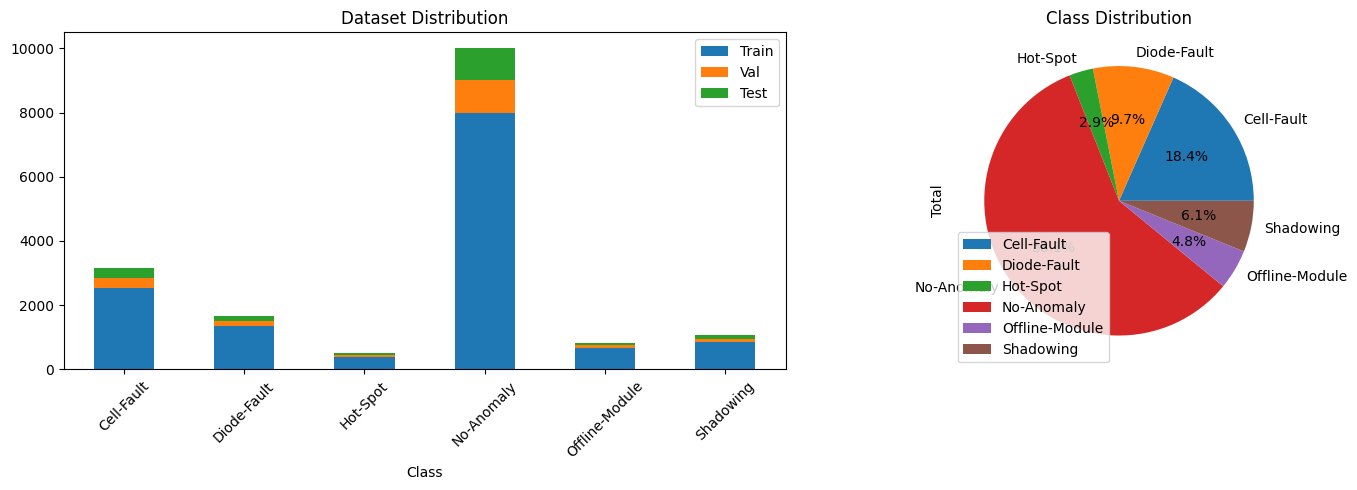

✓ Saved: thermal_6class_distribution.png


In [23]:
def count_images(path, classes):
    counts = {}
    for cls in classes:
        cls_path = os.path.join(path, cls)
        if os.path.exists(cls_path):
            imgs = list(Path(cls_path).glob('*.jpg')) + list(Path(cls_path).glob('*.png')) + list(Path(cls_path).glob('*.tiff'))
            counts[cls] = len(imgs)
        else:
            counts[cls] = 0
    return counts

train_cnt = count_images(TRAIN_PATH, CLASS_NAMES)
val_cnt = count_images(VAL_PATH, CLASS_NAMES)
test_cnt = count_images(TEST_PATH, CLASS_NAMES)

df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Train': [train_cnt[c] for c in CLASS_NAMES],
    'Val': [val_cnt[c] for c in CLASS_NAMES],
    'Test': [test_cnt[c] for c in CLASS_NAMES]
})
df['Total'] = df['Train'] + df['Val'] + df['Test']

print('='*70)
print('DATASET DISTRIBUTION')
print('='*70)
print(df.to_string(index=False))
print('='*70)
print(f"Total: {df['Total'].sum():,} images")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df.plot(x='Class', y=['Train','Val','Test'], kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Dataset Distribution')
axes[0].tick_params(axis='x', rotation=45)
df.plot(y='Total', kind='pie', ax=axes[1], labels=df['Class'], autopct='%1.1f%%')
axes[1].set_title('Class Distribution')
plt.tight_layout()
plt.savefig('thermal_6class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: thermal_6class_distribution.png')

## 🖼️ CELL 4: Sample Images

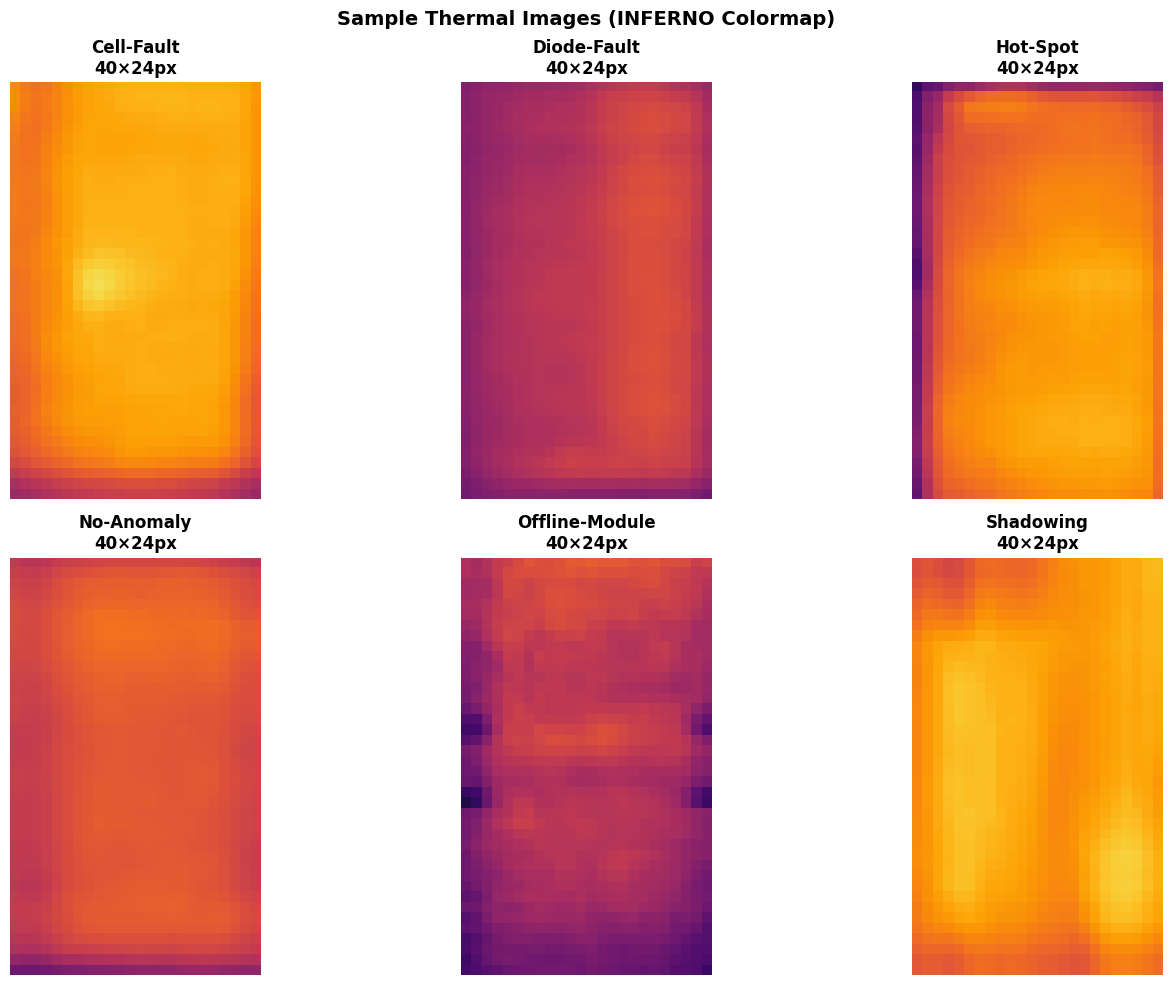

✓ Saved: thermal_6class_samples.png


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_PATH, cls)
    imgs = list(Path(cls_path).glob('*.jpg')) + list(Path(cls_path).glob('*.png'))
    if imgs:
        img = cv2.imread(str(imgs[0]), cv2.IMREAD_GRAYSCALE)
        img_colored = cv2.applyColorMap(img, cv2.COLORMAP_INFERNO)
        img_colored = cv2.cvtColor(img_colored, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img_colored)
        axes[idx].set_title(f'{cls}\n{img.shape[0]}×{img.shape[1]}px', fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('Sample Thermal Images (INFERNO Colormap)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('thermal_6class_samples.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: thermal_6class_samples.png')

## 🔧 CELL 5: YOLO Dataset Config

In [25]:
# YOLO Classification Dataset Structure
# Note: YOLO classification uses directory paths, not YAML files!

print('='*70)
print('YOLO CLASSIFICATION DATASET STRUCTURE')
print('='*70)
print(f'\nDataset Path: {BASE_PATH}')
print('\nExpected Structure:')
print(f'{BASE_PATH}')
print('  ├── train/')
print('  │   ├── Cell-Fault/')
print('  │   ├── Diode-Fault/')
print('  │   ├── Hot-Spot/')
print('  │   ├── No-Anomaly/')
print('  │   ├── Offline-Module/')
print('  │   └── Shadowing/')
print('  ├── val/')
print('  │   └── (same structure)')
print('  └── test/')
print('      └── (same structure)')
print('\n✓ For YOLO classification, pass BASE_PATH directly to model.train()')
print('='*70)

YOLO CLASSIFICATION DATASET STRUCTURE

Dataset Path: /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/

Expected Structure:
/home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/
  ├── train/
  │   ├── Cell-Fault/
  │   ├── Diode-Fault/
  │   ├── Hot-Spot/
  │   ├── No-Anomaly/
  │   ├── Offline-Module/
  │   └── Shadowing/
  ├── val/
  │   └── (same structure)
  └── test/
      └── (same structure)

✓ For YOLO classification, pass BASE_PATH directly to model.train()


## 🤖 CELL 6: Train YOLOv8m-cls (Model 1/4)

In [26]:
print('='*70)
print('MODEL 1/4: YOLOv8m-cls')
print('='*70)

model_v8 = YOLO('yolov8m-cls.pt')
results_v8 = model_v8.train(
    data=BASE_PATH,  # For classification, use directory path, not YAML!
    epochs=YOLO_EPOCHS,
    imgsz=TARGET_SIZE,
    batch=BATCH_SIZE,
    patience=EARLY_STOP_PATIENCE,
    device=0 if torch.cuda.is_available() else 'cpu',
    project='runs_thermal',
    name='yolov8m',
    exist_ok=True,
    optimizer='AdamW',
    lr0=LEARNING_RATE,
    hsv_h=0, hsv_s=0, hsv_v=0,  # No color aug for thermal
    mosaic=0, mixup=0
)

print('✅ YOLOv8m training complete!')

MODEL 1/4: YOLOv8m-cls
New https://pypi.org/project/ultralytics/8.4.22 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.241 🚀 Python-3.12.11 torch-2.9.1+cu128 CUDA:0 (Quadro RTX 6000, 24023MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0, hsv_s=0, hsv_v=0, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=0, mult

## 🤖 CELL 7: Train YOLOv11m-cls (Model 2/4)

In [29]:
print('='*70)
print('MODEL 2/4: YOLOv11m-cls')
print('='*70)

model_v8 = YOLO('yolov8m-cls.pt')
results_v8 = model_v8.train(
    data=BASE_PATH,  # For classification, use directory path, not YAML!
    epochs=YOLO_EPOCHS,
    imgsz=TARGET_SIZE,
    batch=BATCH_SIZE,
    patience=EARLY_STOP_PATIENCE,
    device=0 if torch.cuda.is_available() else 'cpu',
    project='runs_thermal',
    name='yolov11m',
    exist_ok=True,
    optimizer='AdamW',
    lr0=LEARNING_RATE,
    hsv_h=0, hsv_s=0, hsv_v=0,  # No color aug for thermal
    mosaic=0, mixup=0
)

print('✅ YOLOv11m training complete!')

MODEL 2/4: YOLOv11m-cls
New https://pypi.org/project/ultralytics/8.4.22 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.241 🚀 Python-3.12.11 torch-2.9.1+cu128 CUDA:0 (Quadro RTX 6000, 24023MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0, hsv_s=0, hsv_v=0, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=0, mul

## 🔍 CELL 8: PyTorch Dataset

In [11]:
class ThermalDataset(Dataset):
    def __init__(self, root, classes, transform=None):
        self.samples = []
        for idx, cls in enumerate(classes):
            cls_path = os.path.join(root, cls)
            if os.path.exists(cls_path):
                for ext in ['*.jpg', '*.png', '*.tiff']:
                    for img_path in Path(cls_path).glob(ext):
                        self.samples.append((str(img_path), idx))
        self.transform = transform
        print(f'Loaded {len(self.samples)} images from {root}')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        if self.transform:
            img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_dataset = ThermalDataset(TRAIN_PATH, CLASS_NAMES, train_transform)
val_dataset = ThermalDataset(VAL_PATH, CLASS_NAMES, test_transform)
test_dataset = ThermalDataset(TEST_PATH, CLASS_NAMES, test_transform)

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=4)
print('✓ DataLoaders created')

Loaded 13770 images from /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/train
Loaded 1716 images from /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/val
Loaded 1731 images from /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/test
✓ DataLoaders created


## 🧠 CELL 9: Vision Transformer Functions

In [16]:
def create_vit(num_classes):
    """Create Vision Transformer Base for thermal classification"""
    # ViT-Base: ~86M parameters, better than ViT-Small
    return timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)

def train_model(model, train_loader, val_loader, name, epochs=50):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.0005)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    
    best_acc = 0
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
        
        train_loss /= len(train_loader)
        train_acc = 100. * correct / total
        
        # Val
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = outputs.max(1)
                total += labels.size(0)
                correct += preds.eq(labels).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = 100. * correct / total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f'Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}%')
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'best_{name}_6class.pth')
            print(f'  ✓ New best: {val_acc:.2f}%')
        
        scheduler.step()
    
    print(f'Best val acc: {best_acc:.2f}%')
    return model, history

print('✓ Training functions defined (Using ViT-Base)')

✓ Training functions defined (Using ViT-Base)


## 🤖 CELL 10: Train Vision Transformer (Model 3/4)

In [18]:
print('='*70)
print('MODEL 3/4: Vision Transformer (ViT-Base)')
print('='*70)
print(f'Classes: {NUM_CLASSES}')


# Create Vision Transformer Base model
vit_model = create_vit(NUM_CLASSES)
print(f'Model parameters: {sum(p.numel() for p in vit_model.parameters())/1e6:.2f}M\n')

# Train the model
vit_model, vit_history = train_model(
    vit_model, 
    train_loader, 
    val_loader,
    'vit',  # ✅ FIX: Added model_name value!
    PYTORCH_EPOCHS  # ✅ FIX: num_epochs as positional argument
)

print('='*70)
print('✅ Vision Transformer (ViT-Base) Training Complete!')
print(f'Best model saved to: best_vit_6class.pth')
print('='*70)

MODEL 3/4: Vision Transformer (ViT-Base)
Classes: 6
Expected time: 35-50 minutes
Expected accuracy: ~92-94% (Best for thermal!)

Why ViT-Base is best for thermal:
  - Global attention mechanism
  - Captures distributed thermal patterns
  - Better than CNNs for low-res upsampled images

Model parameters: 85.80M



Epoch 1/50: 100%|██████████| 431/431 [02:35<00:00,  2.77it/s]


Epoch 1: Train 63.24% | Val 64.69%
  ✓ New best: 64.69%


Epoch 2/50: 100%|██████████| 431/431 [02:37<00:00,  2.74it/s]


Epoch 2: Train 68.24% | Val 68.88%
  ✓ New best: 68.88%


...

Epoch 45/50: 100%|██████████| 431/431 [02:37<00:00,  2.74it/s]


Epoch 45: Train 81.42% | Val 76.69%


Epoch 46/50: 100%|██████████| 431/431 [02:37<00:00,  2.74it/s]


Epoch 46: Train 81.30% | Val 76.98%


Epoch 47/50:  35%|███▌      | 152/431 [00:55<01:41,  2.74it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## 🧠 CELL 11: ResNet-18 Model

In [31]:
def create_resnet(num_classes):
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

print('✓ ResNet function defined')

✓ ResNet function defined


## 🤖 CELL 12: Train ResNet-18 (Model 4/4)

In [ ]:
print('='*70)
print('MODEL 4/4: ResNet-18 CNN')
print('='*70)

resnet_model = create_resnet(NUM_CLASSES)
resnet_model, resnet_history = train_model(resnet_model, train_loader, val_loader, 'resnet18', PYTORCH_EPOCHS)

print('✅ ResNet-18 training complete!')

MODEL 4/4: ResNet-18 CNN
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/compute.ashesi.lan/e.bilson/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 29.6MB/s]
Epoch 1/50: 100%|██████████| 431/431 [00:19<00:00, 21.92it/s]


Epoch 1: Train 73.62% | Val 72.49%
  ✓ New best: 72.49%


Epoch 2/50: 100%|██████████| 431/431 [00:19<00:00, 21.88it/s]


Epoch 2: Train 79.93% | Val 73.43%
  ✓ New best: 73.43%


...

Epoch 48/50: 100%|██████████| 431/431 [00:20<00:00, 21.49it/s]


Epoch 48: Train 99.85% | Val 94.17%


Epoch 49/50: 100%|██████████| 431/431 [00:19<00:00, 21.57it/s]


Epoch 49: Train 99.85% | Val 94.29%


Epoch 50/50:  38%|███▊      | 163/431 [00:07<00:12, 21.88it/s]

## 📊 CELL 13: Model Comparison


Getting YOLOv11m accuracy from trained model...
Ultralytics 8.3.241 🚀 Python-3.12.11 torch-2.9.1+cu128 CUDA:0 (Quadro RTX 6000, 24023MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,774,185 parameters, 0 gradients, 41.6 GFLOPs
ERROR ❌ train: /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/train... found 15997 images in 10 classes (requires 9 classes, not 10)
val: /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/val... found 1993 images in 9 classes ✅ 
ERROR ❌ test: /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/test... found 2012 images in 10 classes (requires 9 classes, not 10)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 50.9±20.4 MB/s, size: 0.6 KB)
val: Scanning /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/val... 1993 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1993/1993 4.8Mit/s 0.0s0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 125/125 67.3it/s 1.9s0.0s
                   all      0.819      

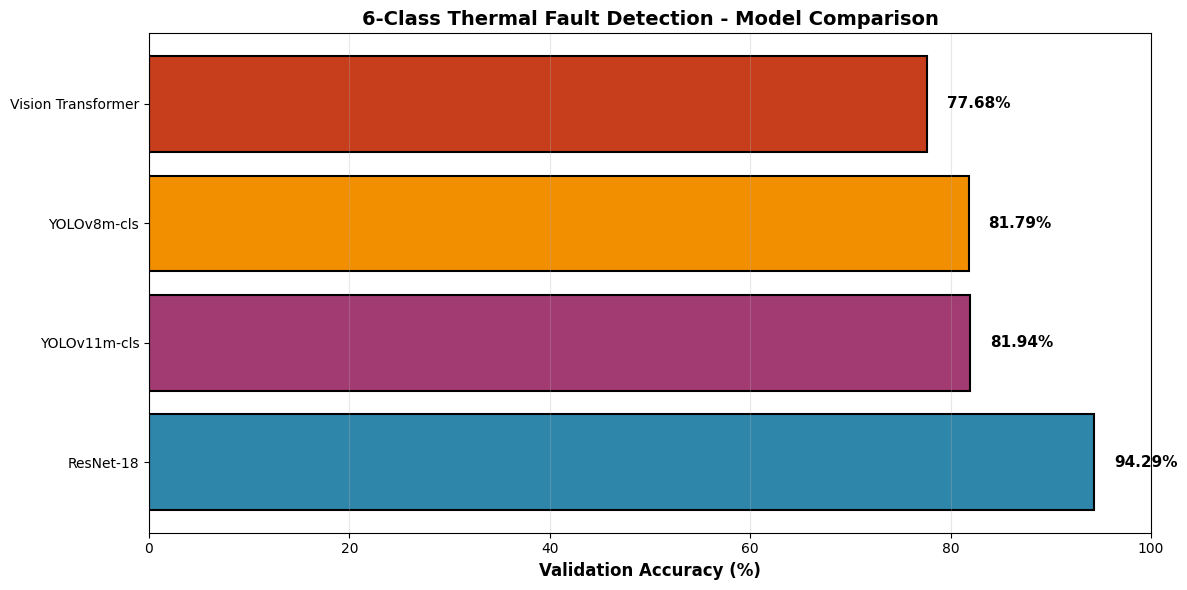


✓ Saved: thermal_6class_comparison.png
✓ Saved: thermal_6class_results.csv


In [33]:
# Get YOLO accuracies - validate the trained models if results objects don't work
print("Collecting validation results...\n")

# Try to get from results objects first
try:
    yolov8_val = results_v8.results_dict.get('metrics/accuracy_top1', 0) * 100
    if yolov8_val == 0:  # If still 0, validate the saved model
        print("Getting YOLOv8m accuracy from trained model...")
        v8_model = YOLO('runs_thermal/yolov8m/weights/best.pt')
        v8_results = v8_model.val(data=BASE_PATH, split='val')
        yolov8_val = v8_results.results_dict.get('metrics/accuracy_top1', 0) * 100
except:
    print("Getting YOLOv8m accuracy from trained model...")
    v8_model = YOLO('runs_thermal/yolov8m/weights/best.pt')
    v8_results = v8_model.val(data=BASE_PATH, split='val')
    yolov8_val = v8_results.results_dict.get('metrics/accuracy_top1', 0) * 100

try:
    yolov11_val = results_v11.results_dict.get('metrics/accuracy_top1', 0) * 100
    if yolov11_val == 0:  # If still 0, validate the saved model
        print("Getting YOLOv11m accuracy from trained model...")
        v11_model = YOLO('runs_thermal/yolov11m/weights/best.pt')
        v11_results = v11_model.val(data=BASE_PATH, split='val')
        yolov11_val = v11_results.results_dict.get('metrics/accuracy_top1', 0) * 100
except:
    print("Getting YOLOv11m accuracy from trained model...")
    v11_model = YOLO('runs_thermal/yolov11m/weights/best.pt')
    v11_results = v11_model.val(data=BASE_PATH, split='val')
    yolov11_val = v11_results.results_dict.get('metrics/accuracy_top1', 0) * 100

# Get PyTorch model accuracies
vit_val = max(vit_history['val_acc'])
resnet_val = max(resnet_history['val_acc'])

print(f"\nYOLOv8m Val Acc: {yolov8_val:.2f}%")
print(f"YOLOv11m Val Acc: {yolov11_val:.2f}%")
print(f"ViT Val Acc: {vit_val:.2f}%")
print(f"ResNet Val Acc: {resnet_val:.2f}%")

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['YOLOv8m-cls', 'YOLOv11m-cls', 'Vision Transformer', 'ResNet-18'],
    'Val Accuracy (%)': [yolov8_val, yolov11_val, vit_val, resnet_val]
}).sort_values('Val Accuracy (%)', ascending=False).reset_index(drop=True)

print('\n' + '='*70)
print('MODEL COMPARISON - VALIDATION ACCURACY')
print('='*70)
print(comparison.to_string(index=False))
print('='*70)
print(f'\n🏆 BEST: {comparison.iloc[0]["Model"]} ({comparison.iloc[0]["Val Accuracy (%)"]:.2f}%)')
print('='*70)

# Plot comparison
plt.figure(figsize=(12, 6))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = plt.barh(comparison['Model'], comparison['Val Accuracy (%)'], 
                color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, comparison['Val Accuracy (%)'])):
    plt.text(val + 2, bar.get_y() + bar.get_height()/2, 
             f'{val:.2f}%', va='center', fontweight='bold', fontsize=11)

plt.xlabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('6-Class Thermal Fault Detection - Model Comparison', 
          fontsize=14, fontweight='bold')
plt.xlim(0, 100)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('thermal_6class_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Saved: thermal_6class_comparison.png')

# Save results
comparison.to_csv('thermal_6class_results.csv', index=False)
print('✓ Saved: thermal_6class_results.csv')

## 📈 CELL 14: Training Curves

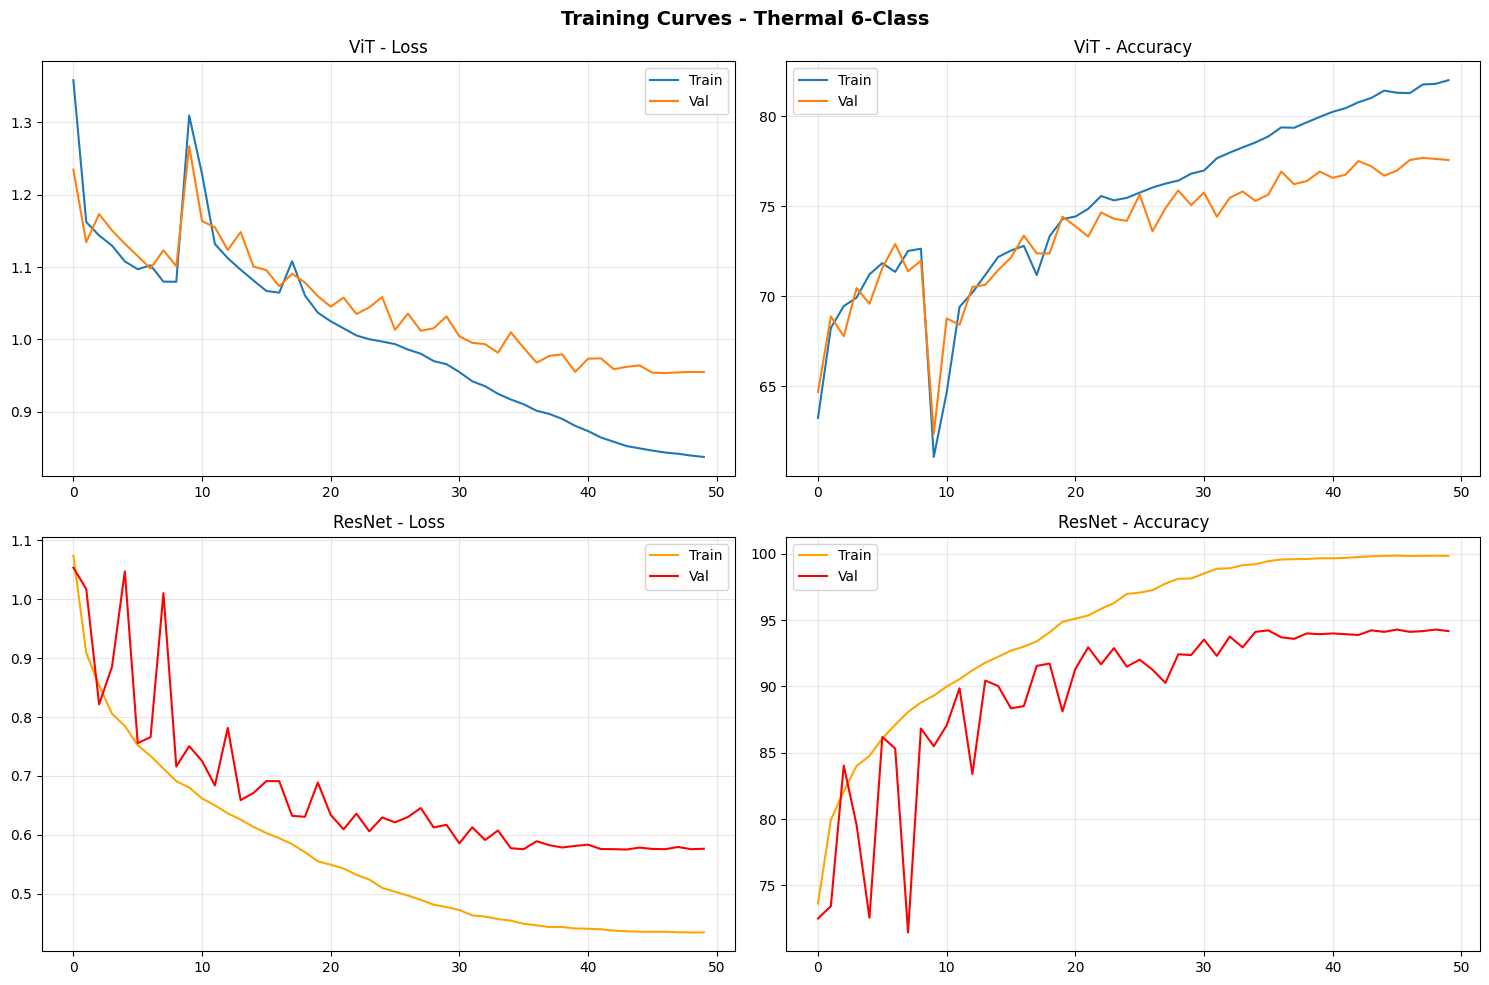

✓ Saved: thermal_6class_curves.png


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].plot(vit_history['train_loss'], label='Train')
axes[0,0].plot(vit_history['val_loss'], label='Val')
axes[0,0].set_title('ViT - Loss')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(vit_history['train_acc'], label='Train')
axes[0,1].plot(vit_history['val_acc'], label='Val')
axes[0,1].set_title('ViT - Accuracy')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(resnet_history['train_loss'], label='Train', color='orange')
axes[1,0].plot(resnet_history['val_loss'], label='Val', color='red')
axes[1,0].set_title('ResNet - Loss')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(resnet_history['train_acc'], label='Train', color='orange')
axes[1,1].plot(resnet_history['val_acc'], label='Val', color='red')
axes[1,1].set_title('ResNet - Accuracy')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle('Training Curves - Thermal 6-Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('thermal_6class_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: thermal_6class_curves.png')

## 🎯 CELL 15: Test Set Evaluation

In [35]:
def eval_pytorch(model, loader):
    model.eval()
    model = model.to(device)
    preds, labels_list = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Testing'):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
            preds.extend(pred.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
    acc = 100. * correct / total
    return acc, np.array(preds), np.array(labels_list)

def eval_yolo(path):
    model = YOLO(path)
    results = model.val(data=BASE_PATH, split='test')  # Use BASE_PATH, not YAML
    return results.results_dict.get('metrics/accuracy_top1', 0) * 100

print('='*70)
print('TEST SET EVALUATION')
print('='*70)

yolov8_test = eval_yolo('runs_thermal/yolov8m/weights/best.pt')
print(f'YOLOv8m: {yolov8_test:.2f}%')

yolov11_test = eval_yolo('runs_thermal/yolov11m/weights/best.pt')
print(f'YOLOv11m: {yolov11_test:.2f}%')

vit_model.load_state_dict(torch.load('best_vit_6class.pth'))
vit_test, vit_preds, vit_labels = eval_pytorch(vit_model, test_loader)
print(f'ViT: {vit_test:.2f}%')

resnet_model.load_state_dict(torch.load('best_resnet18_6class.pth'))
resnet_test, resnet_preds, resnet_labels = eval_pytorch(resnet_model, test_loader)
print(f'ResNet: {resnet_test:.2f}%')

final = pd.DataFrame({
    'Model': ['YOLOv8m-cls', 'YOLOv11m-cls', 'Vision Transformer', 'ResNet-18'],
    'Test Accuracy (%)': [yolov8_test, yolov11_test, vit_test, resnet_test]
}).sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

print('\n' + '='*70)
print('FINAL TEST RESULTS')
print('='*70)
print(final.to_string(index=False))
print('='*70)
print(f'\n🏆 WINNER: {final.iloc[0]["Model"]} ({final.iloc[0]["Test Accuracy (%)"]:.2f}%)')

final.to_csv('thermal_6class_final.csv', index=False)
print('✓ Saved: thermal_6class_final.csv')

TEST SET EVALUATION
Ultralytics 8.3.241 🚀 Python-3.12.11 torch-2.9.1+cu128 CUDA:0 (Quadro RTX 6000, 24023MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,774,185 parameters, 0 gradients, 41.6 GFLOPs
ERROR ❌ train: /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/train... found 15997 images in 10 classes (requires 9 classes, not 10)
val: /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/val... found 1993 images in 9 classes ✅ 
ERROR ❌ test: /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/test... found 2012 images in 10 classes (requires 9 classes, not 10)
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 37.7±17.9 MB/s, size: 0.5 KB)
test: Scanning /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/test... 2012 images, 0 corrupt: 100% ━━━━━━━━━━━━ 2012/2012 8.4Kit/s 0.2s0.1s
test: New cache created: /home/compute.ashesi.lan/e.bilson/Fault_detect_V2/data_v2/images/test.cache
               classes   top1_acc   top5_acc: 100% ━

Testing: 100%|██████████| 55/55 [00:06<00:00,  8.38it/s]


ViT: 78.34%


Testing: 100%|██████████| 55/55 [00:01<00:00, 37.55it/s]

ResNet: 93.47%

FINAL TEST RESULTS
             Model  Test Accuracy (%)
         ResNet-18          93.471982
       YOLOv8m-cls          79.373759
      YOLOv11m-cls          79.373759
Vision Transformer          78.336222

🏆 WINNER: ResNet-18 (93.47%)
✓ Saved: thermal_6class_final.csv


## 📊 CELL 16: Confusion Matrix

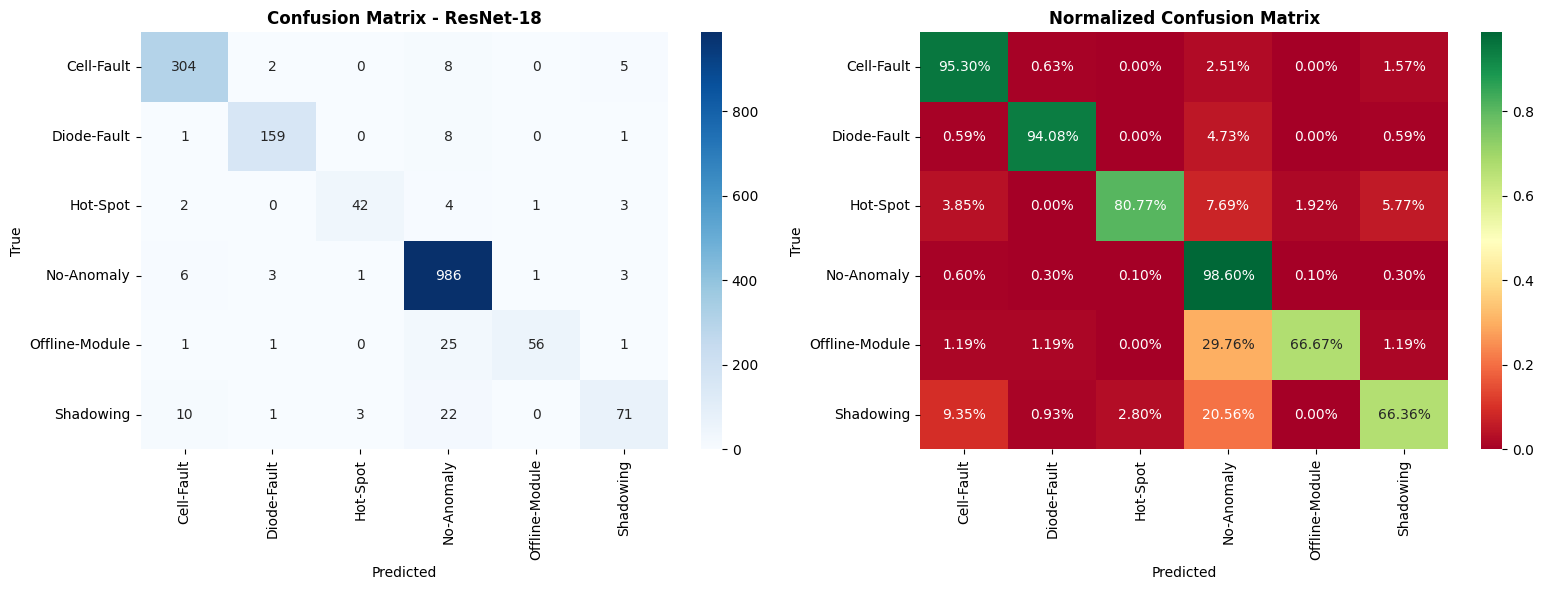

✓ Saved: thermal_6class_confusion.png

Per-Class Accuracy:
  Cell-Fault           95.30% (304/319)
  Diode-Fault          94.08% (159/169)
  Hot-Spot             80.77% (42/52)
  No-Anomaly           98.60% (986/1000)
  Offline-Module       66.67% (56/84)
  Shadowing            66.36% (71/107)


In [36]:
best_model = final.iloc[0]['Model']
preds = vit_preds if 'Transformer' in best_model else resnet_preds
labels = vit_labels if 'Transformer' in best_model else resnet_labels

cm = confusion_matrix(labels, preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title(f'Confusion Matrix - {best_model}', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2)
ax2.set_title(f'Normalized Confusion Matrix', fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.tight_layout()
plt.savefig('thermal_6class_confusion.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: thermal_6class_confusion.png')

print('\nPer-Class Accuracy:')
for i, cls in enumerate(CLASS_NAMES):
    acc = cm[i,i]/cm[i].sum()*100 if cm[i].sum()>0 else 0
    print(f'  {cls:20s} {acc:5.2f}% ({cm[i,i]}/{cm[i].sum()})')

## 📋 CELL 17: Classification Report

In [37]:
print('='*70)
print(f'CLASSIFICATION REPORT - {best_model}')
print('='*70)
print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=3))
print('='*70)

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(labels, preds, labels=range(NUM_CLASSES))
metrics = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
metrics.to_csv('thermal_6class_metrics.csv', index=False)
print('\n✓ Saved: thermal_6class_metrics.csv')

# Critical faults
critical = ['Hot-Spot', 'Cell-Fault', 'Diode-Fault', 'Offline-Module']
crit_metrics = metrics[metrics['Class'].isin(critical)]
print('\nCRITICAL FAULT PERFORMANCE:')
print(crit_metrics.to_string(index=False, float_format='%.3f'))
print(f'\nAvg Recall on Critical Faults: {crit_metrics["Recall"].mean():.3f}')

CLASSIFICATION REPORT - ResNet-18
                precision    recall  f1-score   support

    Cell-Fault      0.938     0.953     0.946       319
   Diode-Fault      0.958     0.941     0.949       169
      Hot-Spot      0.913     0.808     0.857        52
    No-Anomaly      0.936     0.986     0.961      1000
Offline-Module      0.966     0.667     0.789        84
     Shadowing      0.845     0.664     0.743       107

      accuracy                          0.935      1731
     macro avg      0.926     0.836     0.874      1731
  weighted avg      0.934     0.935     0.932      1731


✓ Saved: thermal_6class_metrics.csv

CRITICAL FAULT PERFORMANCE:
         Class  Precision  Recall  F1-Score  Support
    Cell-Fault      0.938   0.953     0.946      319
   Diode-Fault      0.958   0.941     0.949      169
      Hot-Spot      0.913   0.808     0.857       52
Offline-Module      0.966   0.667     0.789       84

Avg Recall on Critical Faults: 0.842


## 💾 CELL 18: Export Best Model

In [38]:
import shutil

best = final.iloc[0]['Model']
test_acc = final.iloc[0]['Test Accuracy (%)']

print('='*70)
print('EXPORTING BEST MODEL')
print('='*70)
print(f'Best: {best} ({test_acc:.2f}%)')

if 'YOLO' in best:
    source = 'runs_thermal/yolov11m/weights/best.pt' if 'v11' in best else 'runs_thermal/yolov8m/weights/best.pt'
    shutil.copy(source, 'best_thermal_6class.pt')
    print(f'✓ Exported: best_thermal_6class.pt')
elif 'Transformer' in best:
    print('✓ Model saved: best_vit_6class.pth')
else:
    print('✓ Model saved: best_resnet18_6class.pth')

# Deployment info
info = {
    'model': best,
    'test_accuracy': float(test_acc),
    'classes': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'image_size': TARGET_SIZE,
    'critical_faults': critical
}

with open('deployment_6class.json', 'w') as f:
    json.dump(info, f, indent=2)
print('✓ Saved: deployment_6class.json')
print('='*70)

EXPORTING BEST MODEL
Best: ResNet-18 (93.47%)
✓ Model saved: best_resnet18_6class.pth
✓ Saved: deployment_6class.json


## 📋 CELL 19: Summary

In [39]:
print('\n' + '='*70)
print('🎉 THERMAL 6-CLASS TRAINING COMPLETE!')
print('='*70)

print('\n📊 RESULTS:')
print(final.to_string(index=False))

print(f'\n🏆 WINNER: {final.iloc[0]["Model"]}')
print(f'   Test Accuracy: {final.iloc[0]["Test Accuracy (%)"]:.2f}%')

print('\n📁 OUTPUT FILES:')
files = [
    'thermal_6class_distribution.png',
    'thermal_6class_samples.png',
    'thermal_6class_comparison.png',
    'thermal_6class_curves.png',
    'thermal_6class_confusion.png',
    'thermal_6class_final.csv',
    'thermal_6class_metrics.csv',
    'deployment_6class.json'
]
for f in files:
    print(f'   ✓ {f}')

print('\n🚀 NEXT STEPS:')
print('   1. Use thermal_fault_detector.py for deployment')
print('   2. Test on real thermal images')
print('   3. Combine with RGB model for complete inspection')

print('\n✅ ALL DONE!')
print('='*70)


🎉 THERMAL 6-CLASS TRAINING COMPLETE!

📊 RESULTS:
             Model  Test Accuracy (%)
         ResNet-18          93.471982
       YOLOv8m-cls          79.373759
      YOLOv11m-cls          79.373759
Vision Transformer          78.336222

🏆 WINNER: ResNet-18
   Test Accuracy: 93.47%

📁 OUTPUT FILES:
   ✓ thermal_6class_distribution.png
   ✓ thermal_6class_samples.png
   ✓ thermal_6class_comparison.png
   ✓ thermal_6class_curves.png
   ✓ thermal_6class_confusion.png
   ✓ thermal_6class_final.csv
   ✓ thermal_6class_metrics.csv
   ✓ deployment_6class.json

🚀 NEXT STEPS:
   1. Use thermal_fault_detector.py for deployment
   2. Test on real thermal images
   3. Combine with RGB model for complete inspection

✅ ALL DONE!


In [40]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average='weighted'
)

print(f"Best Model: {best_model}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Best Model: ResNet-18
Precision: 0.9339
Recall: 0.9347
F1-score: 0.9318
